In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from src.config import QDRANT_URL, QDRANT_API_KEY, OPENAI_API_KEY, OPENAI_MODEL, OPENAI_API_URL,\
     DENSE_EMBEDDING_MODEL_PATH, OPENAI_MODEL_MINI, INTERIM_DATA_DIR, PROCESSED_DATA_DIR, DEVICE, \
     DEEPSEEK_MODEL

from src.generation_metrics import (
    run_generation_evaluation_pipeline,
    compute_generation_metrics,
    combine_generation_metrics,
)
from src.plots import plot_combined_generation_metrics

/home/user/cursor_projects/vanna-sql/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
url = os.path.join(PROCESSED_DATA_DIR, "sakila", "sakila_inline_short.sqlite.db")
DATABASE_NAME = "sakila"


sqlite_config = {
    "params": {
        "url": str(url) 
    },
    "type": "sqlite"}

qdrant_config = {"fastembed_model": DENSE_EMBEDDING_MODEL_PATH,
                 "url": QDRANT_URL, 
                 "api_key": QDRANT_API_KEY,
                 "device": DEVICE}

openai_config = {"api_key": OPENAI_API_KEY,
                 "model": OPENAI_MODEL,
                 "base_url": OPENAI_API_URL,
                 "temperature": 0.01}

In [3]:
rewritten_descriptions_csv_path = os.path.join(INTERIM_DATA_DIR, DATABASE_NAME, "query_descriptions", "query_descriptions_inline_short_rewritten.csv")

### Check generation quality using the same SQL-description that was used to generate ground truth SQL-scripts

In [ ]:

predicted_dirs = run_generation_evaluation_pipeline(
    descriptions_csv_path=rewritten_descriptions_csv_path,
    interim_dir=INTERIM_DATA_DIR,
    database_name=DATABASE_NAME,
    models={
        "mini": OPENAI_MODEL_MINI,
        "gpt5": OPENAI_MODEL,
    },
    qdrant_config=qdrant_config,
    openai_config=openai_config,
    comment_styles=("inline", ),
    description_styles=("short", "business"),
    db_config=sqlite_config,
    n_folds=2,
    source_column="query",
)

print("Predicted result dirs:", predicted_dirs)

In [ ]:
ground_truth_results_dir = INTERIM_DATA_DIR / DATABASE_NAME / "results"

generation_metrics_paths_source_column_query = compute_generation_metrics(
    ground_truth_results_dir=ground_truth_results_dir,
    predicted_results_dirs=predicted_dirs,
    descriptions_csv_path=rewritten_descriptions_csv_path,
)

for path in generation_metrics_paths_source_column_query:
    print(path.name)
    df = pd.read_csv(path)
    display(df.groupby("difficulty")['label'].value_counts())

inline_short_mini_query.csv


difficulty  label                               
easy        Everything matches                      2
hard        Not matching number of rows and cols    2
medium      Not generated                           1
            Not matching values                     1
Name: count, dtype: int64

inline_business_mini_query.csv


difficulty  label                               
easy        Not matching values                     2
hard        Not matching number of rows and cols    2
medium      Not generated                           1
            Not matching values                     1
Name: count, dtype: int64

inline_short_gpt5_query.csv


difficulty  label                               
easy        Everything matches                      2
hard        Not matching number of columns          1
            Not matching number of rows and cols    1
medium      Not generated                           1
            Not matching values                     1
Name: count, dtype: int64

inline_business_gpt5_query.csv


difficulty  label                               
easy        Everything matches                      2
hard        Not matching number of columns          1
            Not matching number of rows and cols    1
medium      Not generated                           1
            Not matching values                     1
Name: count, dtype: int64

In [9]:
combined_query_path = combine_generation_metrics(
    generation_metrics_paths=generation_metrics_paths_source_column_query,
    database_name=DATABASE_NAME,
    source_column="query",
)
plot_saved_paths = plot_combined_generation_metrics(
    combined_query_path,
    style_filters=[("inline", "short"), ("inline", "business")],
)
print("Combined query metrics:", combined_query_path)
display(pd.read_excel(combined_query_path, index_col=[0, 1, 2, 3]))


Combined query metrics: /home/user/cursor_projects/vanna-sql/data/processed/sakila/metrics/combined_generation_query.xlsx


Everything matches  \
difficulty model_name comment_style description_style                       
easy       gpt5       inline        business                            1   
                                    short                               2   
           mini       inline        business                            2   
                                    short                               2   
medium     gpt5       inline        business                            0   
                                    short                               0   
           mini       inline        business                            0   
                                    short                               0   
hard       gpt5       inline        business                            0   
                                    short                               0   
           mini       inline        business                            0   
                                    short                               0   

                                                       Not matching values  \
difficulty model_name comment_style description_style                        
easy       gpt5       inline        business                             1   
                                    short                                0   
           mini       inline        business                             0   
                                    short                                0   
medium     gpt5       inline        business                             0   
                                    short                                1   
           mini       inline        business                             0   
                                    short                                1   
hard       gpt5       inline        business                             0   
                                    short                                0   
           mini       inline        business                             0   
                                    short                                0   

                                                       Not matching number of columns  \
difficulty model_name comment_style description_style                                   
easy       gpt5       inline        business                                        0   
                                    short                                           0   
           mini       inline        business                                        0   
                                    short                                           0   
medium     gpt5       inline        business                                        1   
                                    short                                           0   
           mini       inline        business                                        0   
                                    short                                           0   
hard       gpt5       inline        business                                        1   
                                    short                                           0   
           mini       inline        business                                        0   
                                    short                                           0   

                                                       Not matching number of rows  \
difficulty model_name comment_style description_style                                
easy       gpt5       inline        business                                     0   
                                    short                                        0   
           mini       inline        business                                     0   
                                    short                                        0   
medium     gpt5       inline        business                                     0   
                                  

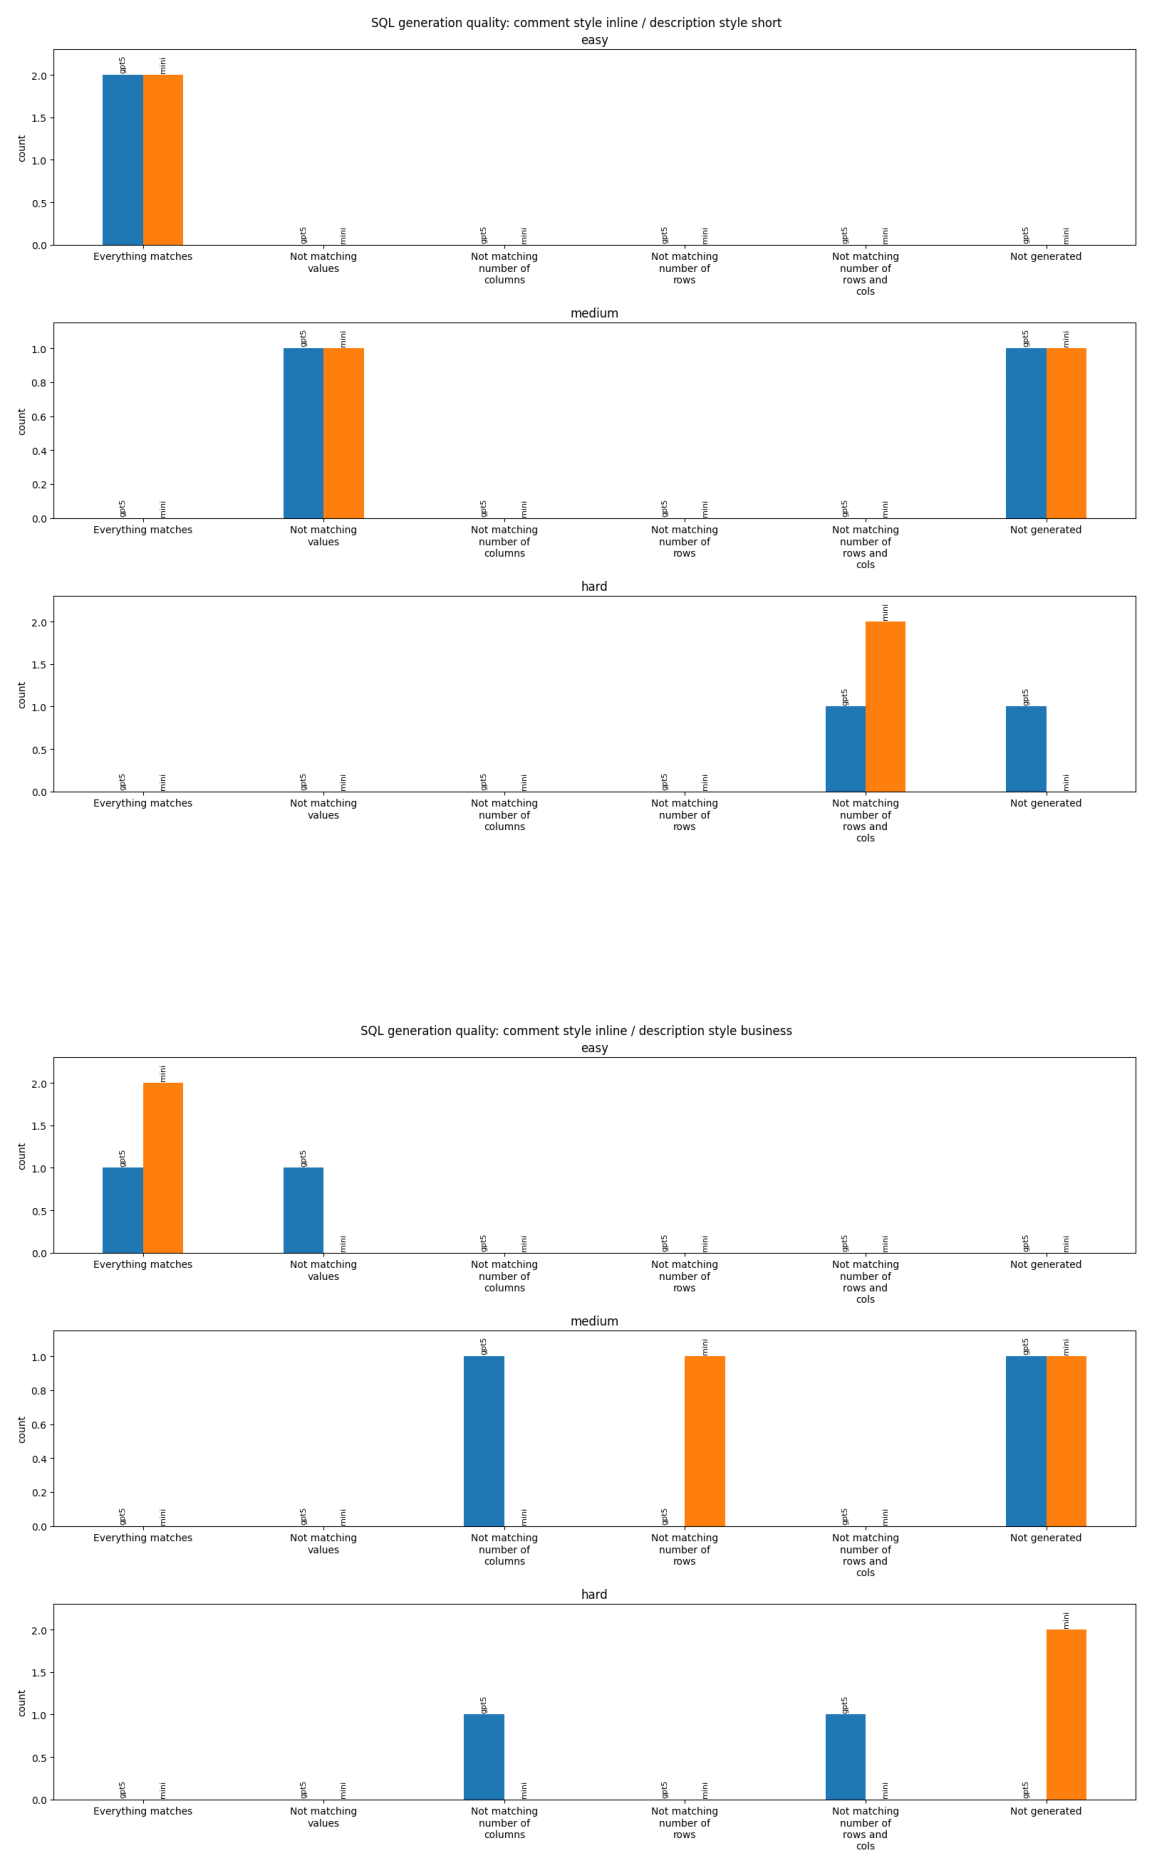

In [10]:
fig = plt.figure(figsize=(20, 12 * len(plot_saved_paths)))
for index, plot_path in enumerate(plot_saved_paths):
    img = mpimg.imread(plot_path)
    fig.add_subplot(len(plot_saved_paths), 1, index + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()

### Check generation quality using rewritten query descriptions in different styles, instead of using original query description used for generating ground truth SQL-scripts

In [ ]:

predicted_dirs = run_generation_evaluation_pipeline(
    descriptions_csv_path=rewritten_descriptions_csv_path,
    interim_dir=INTERIM_DATA_DIR,
    database_name=DATABASE_NAME,
    models={
        "mini": OPENAI_MODEL_MINI,
        "gpt5": OPENAI_MODEL,
    },
    qdrant_config=qdrant_config,
    openai_config=openai_config,
    comment_styles=("inline", ),
    description_styles=("short", "business",),
    db_config=sqlite_config,
    n_folds=2,
)

print("Predicted result dirs:", predicted_dirs)

In [8]:
ground_truth_results_dir = INTERIM_DATA_DIR / DATABASE_NAME / "results"

generation_metrics_paths = compute_generation_metrics(
    ground_truth_results_dir=ground_truth_results_dir,
    predicted_results_dirs=predicted_dirs,
    descriptions_csv_path=rewritten_descriptions_csv_path,
)

for path in generation_metrics_paths:
    print(path.name)
    df = pd.read_csv(path)
    display(df.groupby("difficulty")['label'].value_counts())

inline_short_mini.csv


difficulty  label                               
easy        Everything matches                      2
hard        Not matching number of rows and cols    2
medium      Not generated                           1
            Not matching values                     1
Name: count, dtype: int64

inline_business_mini.csv


difficulty  label                      
easy        Everything matches             2
hard        Not generated                  1
            Not matching number of rows    1
medium      Not generated                  1
            Not matching number of rows    1
Name: count, dtype: int64

inline_short_gpt5.csv


difficulty  label                               
easy        Everything matches                      2
hard        Not generated                           1
            Not matching number of rows and cols    1
medium      Not generated                           1
            Not matching values                     1
Name: count, dtype: int64

inline_business_gpt5.csv


difficulty  label                               
easy        Everything matches                      1
            Not matching number of columns          1
hard        Not matching number of rows and cols    2
medium      Not generated                           1
            Not matching number of rows and cols    1
Name: count, dtype: int64

In [4]:
combined_rewritten_path = combine_generation_metrics(
    generation_metrics_paths=generation_metrics_paths,
    database_name=DATABASE_NAME,
    source_column=None,
)
plot_saved_rewritten_paths = plot_combined_generation_metrics(
    combined_rewritten_path,
    style_filters=[("inline", "short"), ("inline", "business")],
)
print("Combined rewritten metrics:", combined_rewritten_path)
display(pd.read_excel(combined_rewritten_path))

Combined rewritten metrics: /home/user/cursor_projects/vanna-sql/data/processed/sakila/metrics/combined_generation_rewritten.xlsx


,difficulty,model_name,comment_style,description_style,Everything matches,Not matching values,Not matching number of columns,Not matching number of rows,Not matching number of rows and cols,Not generated
0,easy,gpt5,inline,business,1,1,0,0,0,0
1,NaN,NaN,NaN,short,2,0,0,0,0,0
2,NaN,mini,inline,business,2,0,0,0,0,0
3,NaN,NaN,NaN,short,2,0,0,0,0,0
4,medium,gpt5,inline,business,0,0,1,0,0,1
5,NaN,NaN,NaN,short,0,1,0,0,0,1
6,NaN,mini,inline,business,0,0,0,1,0,1
7,NaN,NaN,NaN,short,0,1,0,0,0,1
8,hard,gpt5,inline,business,0,0,1,0,1,0
9,NaN,NaN,NaN,short,0,0,0,0,1,1


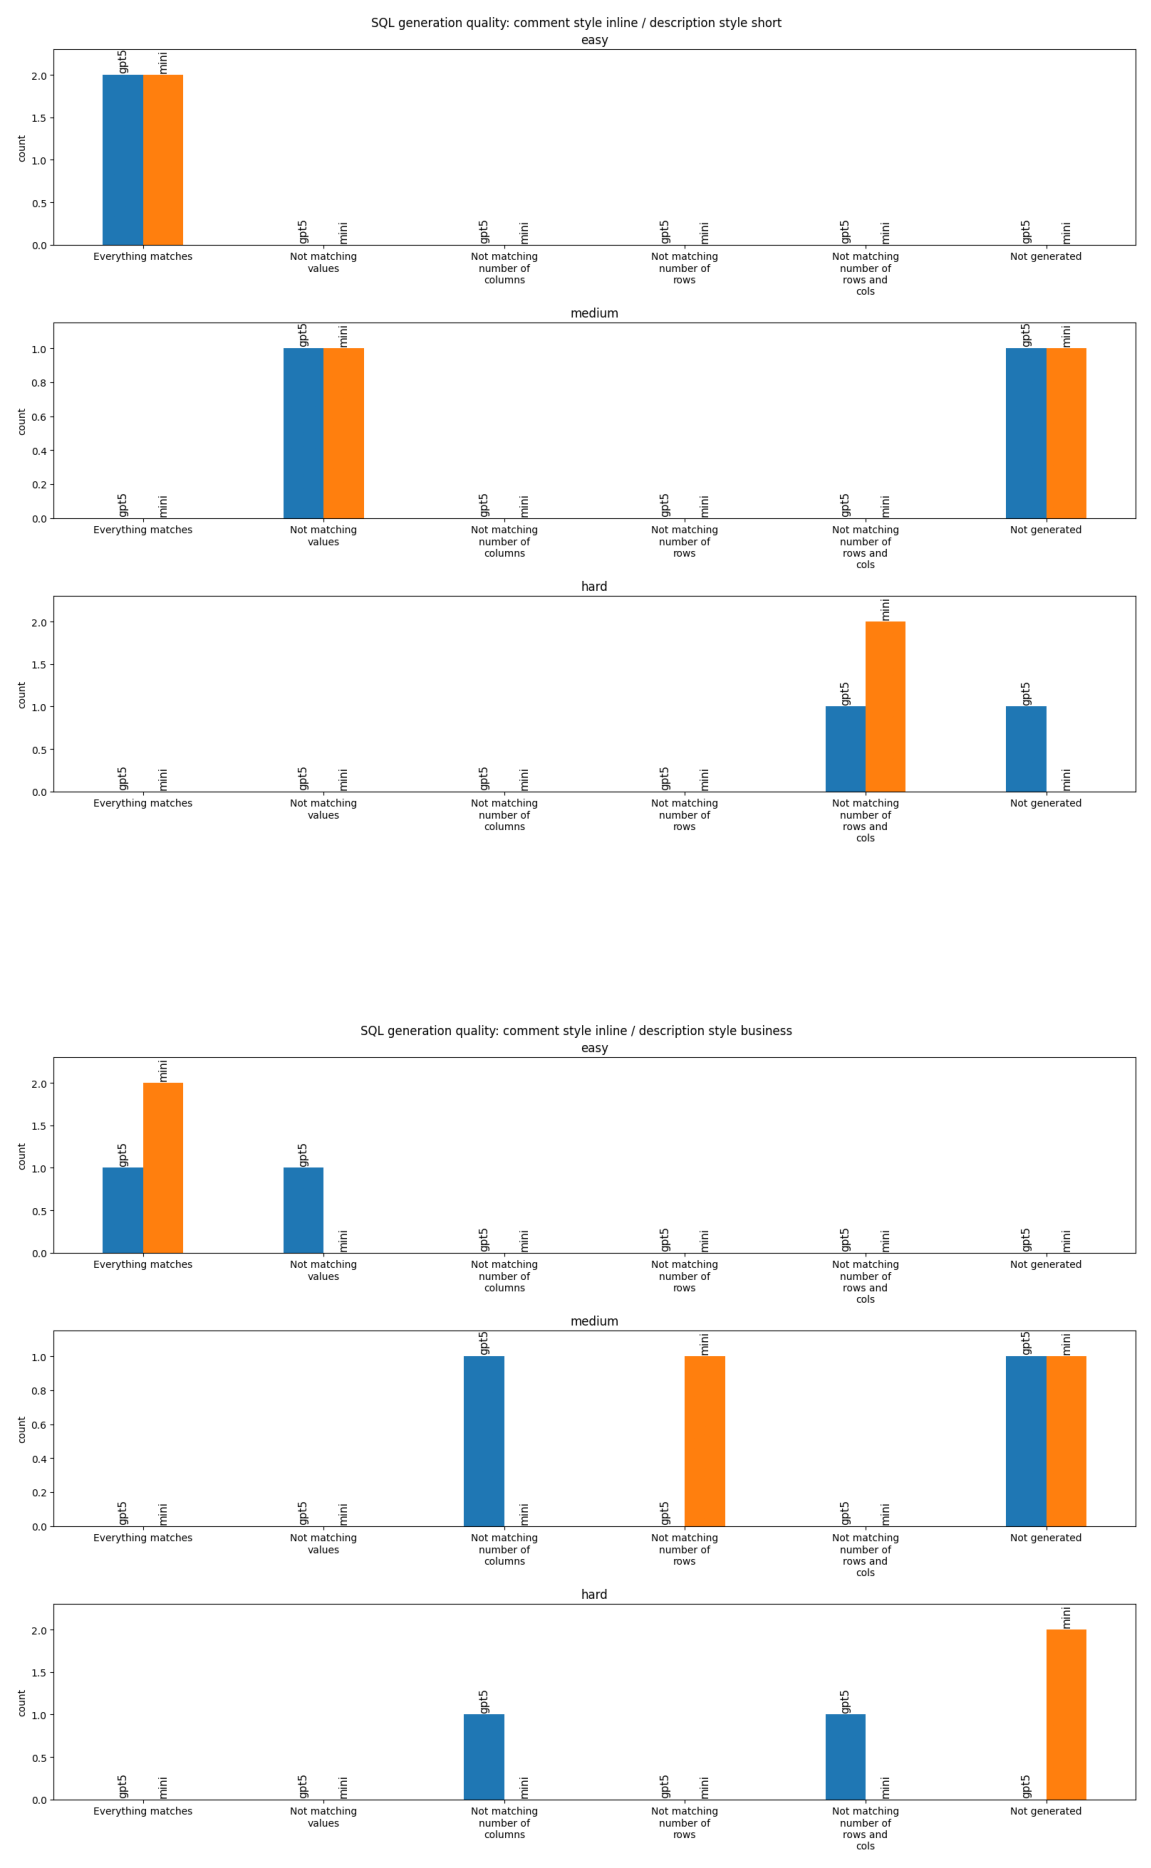

In [5]:
fig = plt.figure(figsize=(20, 12 * len(plot_saved_rewritten_paths)))
for index, plot_path in enumerate(plot_saved_rewritten_paths):
    img = mpimg.imread(plot_path)
    fig.add_subplot(len(plot_saved_rewritten_paths), 1, index + 1)
    plt.imshow(img)
    plt.axis('off')
plt.show()